In [1]:
# install the input image
!gdown '1FfSpH46ozPWTe1AdTS2NXA_Un8KyZp2z'

Downloading...
From: https://drive.google.com/uc?id=1FfSpH46ozPWTe1AdTS2NXA_Un8KyZp2z
To: /content/cat.jpg
100% 54.3k/54.3k [00:00<00:00, 55.5MB/s]


# Section 1
Read and show the image

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

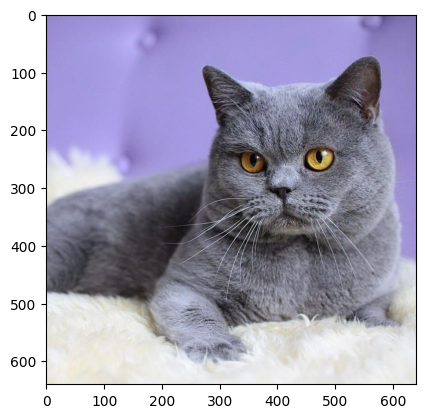

In [3]:
# Answer your code here
cat_pic = cv.imread('cat.jpg')
cat_rgb = cv.cvtColor(cat_pic, cv.COLOR_BGR2RGB)
plt.imshow(cat_rgb)
plt.show()

# Section 2
Apply a 3x3 average filter to an input image whose convolution kernel is:

$$
K = \frac{1}{9}
\begin{bmatrix}
1 & 1 & 1  \\
1 & 1 & 1 \\
1 & 1 & 1  \\
\end{bmatrix}
$$

Filter the input image using the function cv.filter2D() and display the results.

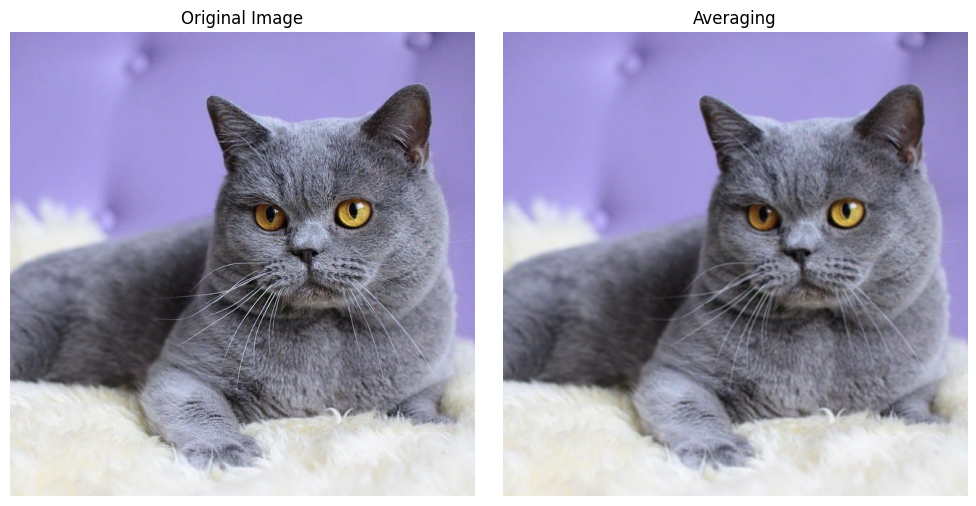

In [4]:
# Answer your code here
kernel = np.ones((3, 3), np.float32) / 9
dst_Conv = cv.filter2D(cat_pic, -1, kernel)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(cat_pic, cv.COLOR_BGR2RGB))
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(dst_Conv, cv.COLOR_BGR2RGB))
plt.title('Averaging')
plt.axis('off')

plt.tight_layout()
plt.show()


# Section 3
- Add Gaussian noise to an image using the provided function add_gaussian_noise().

- Use cv.GaussianBlur() to denoise and adjust the size of the blur kernel (e.g. : (3, 3), (11, 11) etc.) and sigma (e.g., 1, 2, 5 etc). Then observe and explain its influence on the denoising effect.

**P.S. for the adjusting kernel and sigma, you can try any combination you like, for example: 3x3 kernel with sigma 1 and 11x11 with sigma 1 or 9x9 with sigma 1 and 9x9 with sigma 3**

- Display and compare the following three images (two pairs):

  1. Original image

  2. Image after adding Gaussian noise

  3. Image after applying Gaussian blur

  



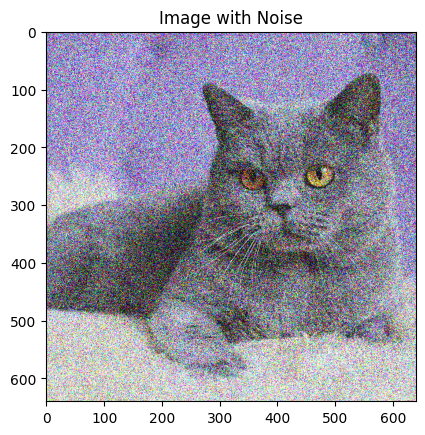

In [5]:
# Adding gaussian noise
def add_gaussian_noise(image, mean=0, sigma=100):
    noise = np.random.normal(mean, sigma, image.shape) # generate noise
    noisy_image = image + noise #  add noise to the image
    noisy_image = np.clip(noisy_image, 0, 255)
    return noisy_image.astype(np.uint8)

noisy_img = add_gaussian_noise(cat_pic)

plt.imshow(cv.cvtColor(noisy_img, cv.COLOR_BGR2RGB))
plt.title("Image with Noise")
plt.show()


after use GaussianBlur() with noisy image
on my eyes it like a original image before add noise
that mean GaussianBlur() can remove gaussian noise




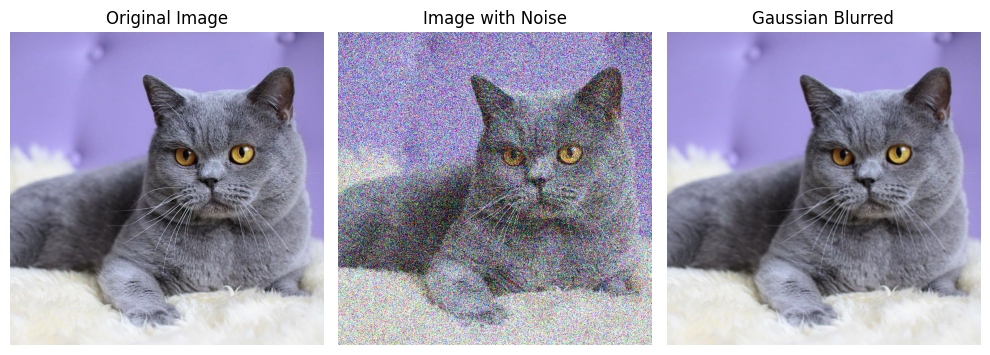

In [8]:
# Answer your code here
noisy_img = add_gaussian_noise(cat_pic)
Gblur = cv.GaussianBlur(cat_pic,(3,3),1)

print("""
after use GaussianBlur() with noisy image
on my eyes it like a original image before add noise
that mean GaussianBlur() can remove gaussian noise\n
""")
plt.figure(figsize=(10, 5))

plt.subplot(1, 3, 1)
plt.imshow(cv.cvtColor(cat_pic, cv.COLOR_BGR2RGB))
plt.title("Original Image")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(cv.cvtColor(noisy_img, cv.COLOR_BGR2RGB))
plt.title("Image with Noise")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv.cvtColor(Gblur, cv.COLOR_BGR2RGB))
plt.title("Gaussian Blurred")
plt.axis('off')

plt.tight_layout()
plt.show()

# Section 4
- Add salt and pepper noise to an image using the provided add_salt_and_pepper_noise() function.
- Adjust the ratio parameters of salt_prob and pepper_prob to observe the effect of noise on the image. (2 different ratio parameters)
- Apply Medianblur (cv2.medianBlur) to the image after adding noise, and adjust the blur kernel size to try to denoise. (2 different kernel size)
- Show and compare the results.

**P.S. for the comparison of different adjustment, you can try any combination you like, the one you think you will get good result. For example: 0.5 ratio of noises with 3x3 kernel and 0.05 ratio of noises with 11x11 kernel or salt noises 0.2 pepper noises 0.3 with kernel 3x3 and salt noises 0.2 pepper noises 0.3 with kernel 11x11**

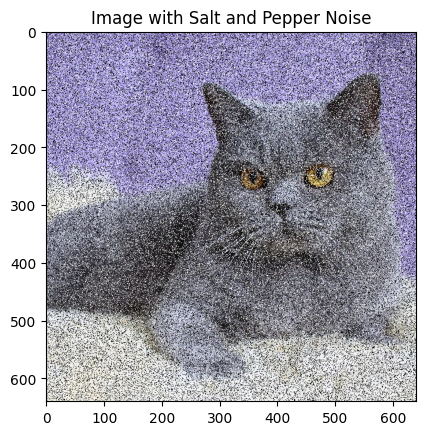

In [9]:
def add_salt_and_pepper_noise(image, salt_prob=0.02, pepper_prob=0.02):
    noisy_image = image.copy()
    # get image size
    total_pixels = image.size // image.shape[2]
    # calculate the number of noises
    num_salt = int(total_pixels * salt_prob)
    num_pepper = int(total_pixels * pepper_prob)

    # Add salt noises
    for _ in range(num_salt):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0]) # # Generate random coordinates (x, y)
        noisy_image[y, x] = [255, 255, 255] # white

    # Add pepper noises
    for _ in range(num_pepper):
        x, y = np.random.randint(0, image.shape[1]), np.random.randint(0, image.shape[0])
        noisy_image[y, x] = [0, 0, 0]  # black

    return noisy_image

# Add salt-and-pepper noises to the image
salt_and_pepper_noisy_img = add_salt_and_pepper_noise(cat_pic, salt_prob=0.2, pepper_prob=0.2)

plt.imshow(cv.cvtColor(salt_and_pepper_noisy_img, cv.COLOR_BGR2RGB))
plt.title("Image with Salt and Pepper Noise")
plt.show()

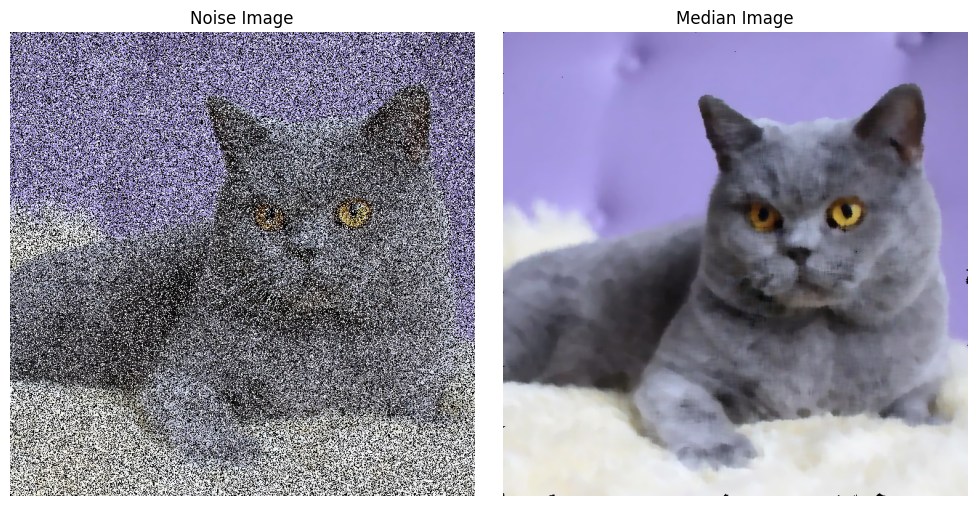

In [12]:
# Answer your code here
salt_and_pepper_noisy_img = add_salt_and_pepper_noise(cat_pic, salt_prob=0.3, pepper_prob=0.4)
median = cv.medianBlur(salt_and_pepper_noisy_img, 11)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(salt_and_pepper_noisy_img, cv.COLOR_BGR2RGB))
plt.title("Noise Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(median, cv.COLOR_BGR2RGB))
plt.title("Median Image")
plt.axis('off')

plt.tight_layout()
plt.show()

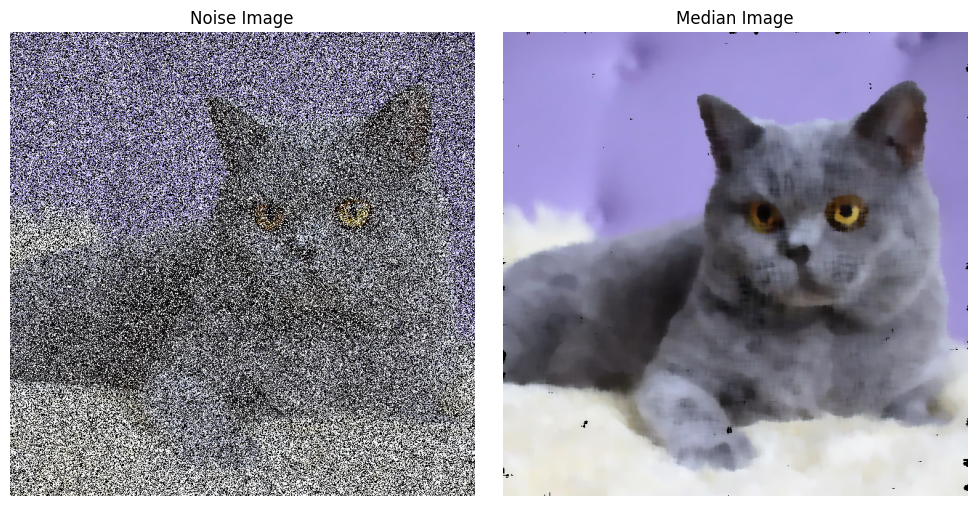

In [17]:
# Answer your code here
salt_and_pepper_noisy_img = add_salt_and_pepper_noise(cat_pic, salt_prob=0.5, pepper_prob=0.5)
median = cv.medianBlur(salt_and_pepper_noisy_img, 15)

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(cv.cvtColor(salt_and_pepper_noisy_img, cv.COLOR_BGR2RGB))
plt.title("Noise Image")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv.cvtColor(median, cv.COLOR_BGR2RGB))
plt.title("Median Image")
plt.axis('off')

plt.tight_layout()
plt.show()

# Section 5
Fourier Transform

Use the given image "Lenna" to :
1. Perform the Fourier Transform of the input image and display its magnitude spectrum.

2. Implement the Low-Pass Filter (LPF) using NumPy and the High-Pass Filter (HPF) using OpenCV. Apply both filters to the same input image and compare the output results.

3. Compare how LPF and HPF affect the image. Explain how they influence image sharpness, edges, details, and smoothness.

4. Modify the mask size to 10, 30, 100.
Observe and explain the resulting 2 types of filtered images (LPF and HPF) for different mask sizes.

*For explanation part you can answer in both Thai & English language.*

In [18]:
!gdown '1FNXTuv3OcIg-6o8D9XlhVHhMHGiuAQLA'

Downloading...
From: https://drive.google.com/uc?id=1FNXTuv3OcIg-6o8D9XlhVHhMHGiuAQLA
To: /content/Lenna.png
100% 194k/194k [00:00<00:00, 101MB/s]


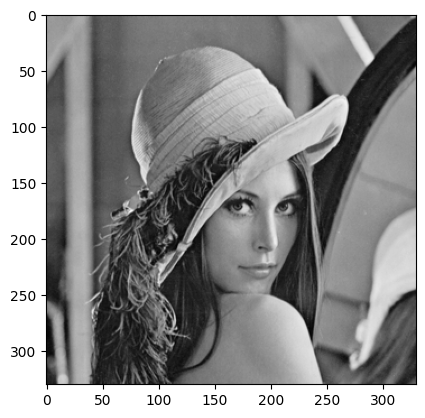

In [20]:
# Answer your code here
# Read the image as grayscale and display.
lenna_pic = cv.imread('Lenna.png')
lenna_gray = cv.cvtColor(lenna_pic, cv.COLOR_BGR2GRAY)
plt.imshow(lenna_gray, cmap='gray')
plt.show()

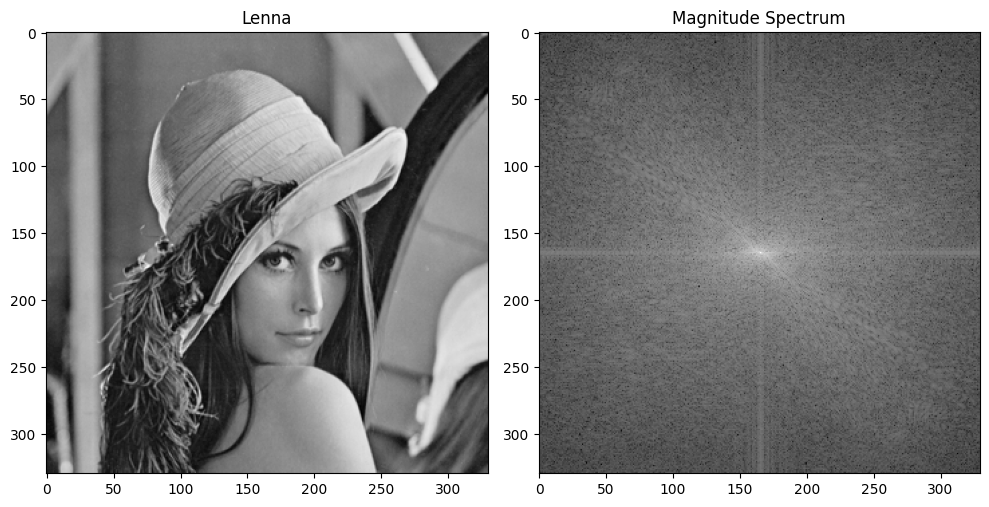

In [47]:
# Answer your code here
f = np.fft.fft2(lenna_gray)
fshift = np.fft.fftshift(f)
magnitude_spectrum = 20*np.log(np.abs(fshift)+1)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2,1)
plt.imshow(lenna_gray, cmap='gray')
plt.title('Lenna')

plt.subplot(1, 2,2)
plt.imshow(magnitude_spectrum, cmap='gray')
plt.title('Magnitude Spectrum')

plt.tight_layout()
plt.show()


when mask size increase like 10, 30, 100
on low pass filter become less blure that mean image have more detail
on high pass filter loss more texture and highlight only strong edge




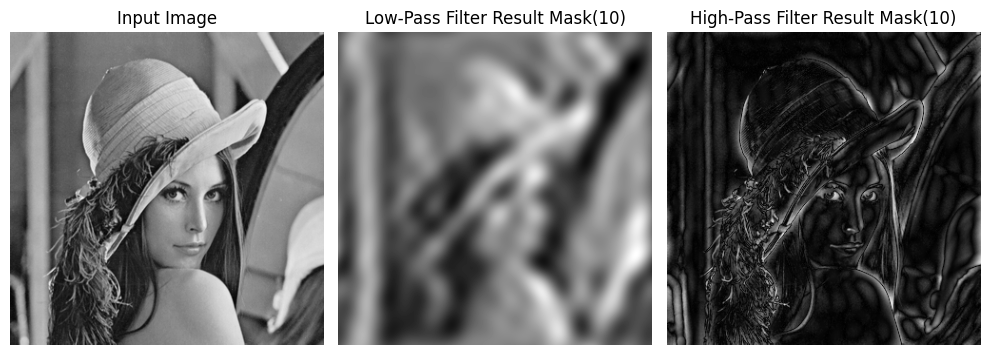

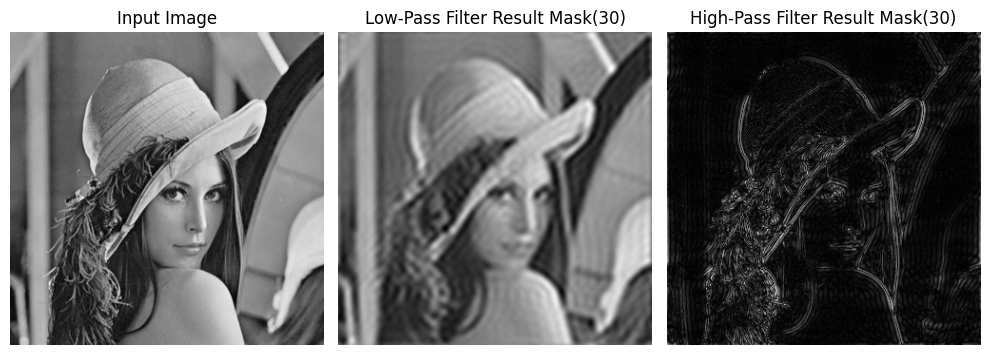

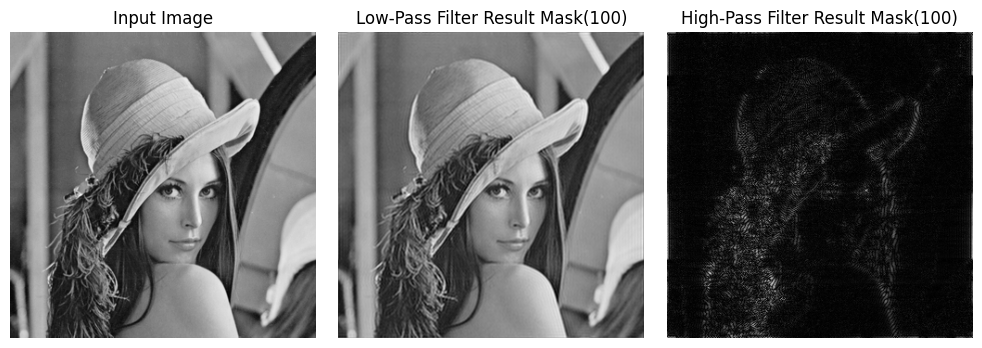

In [62]:
print("""
when mask size increase like 10, 30, 100
on low pass filter become less blure that mean image have more detail
on high pass filter loss more texture and highlight only strong edge\n
""")

for i, mask_size in enumerate([10, 30, 100], 1):
  # Low pass filter
  rows, cols = lenna_gray.shape
  crow, ccol = rows//2, cols//2

  mask = np.zeros((rows, cols), dtype=np.uint8)
  mask[crow-mask_size:crow+mask_size, ccol-mask_size:ccol+mask_size] = 1

  fshift_low_pass = fshift * mask

  f_ishift = np.fft.ifftshift(fshift_low_pass)
  img_back_lowpass = np.fft.ifft2(f_ishift)
  img_back_lowpass = np.real(img_back_lowpass)

  # High pass filter
  dft = cv.dft(np.float32(lenna_gray), flags=cv.DFT_COMPLEX_OUTPUT)
  dft_shift = np.fft.fftshift(dft)

  dft_shift[crow-mask_size:crow+mask_size, ccol-mask_size:ccol+mask_size] = 0
  f_ishift = np.fft.ifftshift(dft_shift)
  img_back_highpass = cv.idft(f_ishift)
  img_back_highpass = cv.magnitude(img_back_highpass[:, :, 0], img_back_highpass[:, :, 1])


  plt.figure(figsize=(10, 10))

  plt.subplot(i, 3, 1)
  plt.imshow(lenna_gray, cmap='gray')
  plt.title('Input Image')
  plt.axis('off')

  plt.subplot(i, 3, 2)
  plt.imshow(img_back_lowpass, cmap='gray')
  plt.title(f'Low-Pass Filter Result Mask({mask_size})')
  plt.axis('off')

  plt.subplot(i, 3, 3)
  plt.imshow(img_back_highpass, cmap='gray')
  plt.title(f'High-Pass Filter Result Mask({mask_size})')
  plt.axis('off')

  plt.tight_layout()
  plt.show()